In [200]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
pd.set_option('display.max_columns', None)
from sklearn.neighbors import NearestNeighbors
import ahocorasick
from pyproj import Transformer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


In [173]:
df_divar = pd.read_csv('Divar.csv')
df_city = pd.read_csv('iran_city_classification.csv')
df_divar = df_divar.merge(df_city ,  left_on='city_slug' , right_on='نام شهر' , how='left')
df_divar = df_divar.drop(columns='نام شهر')  

C:\Users\Toranj\AppData\Local\Temp\ipykernel_14388\1474697002.py:1: DtypeWarning: Columns (0: rent_to_single, 1: floor, 2: total_floors_count, 3: extra_person_capacity) have mixed types. Specify dtype option on import or set low_memory=False.
  df_divar = pd.read_csv('Divar.csv')


In [174]:

def numeric_or_nan(series):
    return series.apply(lambda x: np.nan if isinstance(x, bool) else x).astype(float)

df_divar['transformable_price_n']  = numeric_or_nan(df_divar['transformable_price'])
df_divar['transformable_credit_n'] = numeric_or_nan(df_divar['transformable_credit'])
df_divar['transformable_rent_n']   = numeric_or_nan(df_divar['transformable_rent'])

is_daily = df_divar['cat2_slug'].eq('temporary-rent')
is_sale  = df_divar['cat2_slug'].str.endswith('-sell', na=False) | df_divar['cat3_slug'].isin(['plot-old', 'presell'])
is_rent  = df_divar['cat2_slug'].str.endswith('-rent', na=False) & ~is_daily

sale_price = df_divar['transformable_price_n'].fillna(df_divar['price_value'])
credit = df_divar['transformed_credit'].fillna(df_divar['transformable_credit_n']).fillna(df_divar['credit_value'])
rent = df_divar['transformed_rent'].fillna(df_divar['transformable_rent_n']).fillna(df_divar['rent_value'])
rent_price = rent * 30 + credit 
daily_price = df_divar[['rent_price_on_regular_days' , 'rent_price_on_special_days' , 'rent_price_at_weekends']].mean(axis=1)


df_divar['comparable_price'] = np.select(
    [is_sale, is_rent, is_daily],
    [sale_price, rent_price, daily_price],
    default=np.nan
)

df_divar['price_basis'] = np.select(
    [is_sale, is_rent, is_daily],
    ['sale', 'rent_credit', 'daily_rent'],
    default='unknown'
)

df_divar['comparable_price'] = pd.to_numeric(df_divar['comparable_price'], errors='coerce')



In [175]:

known = df_divar[df_divar['neighborhood_slug'].notna() &  df_divar['location_latitude'].notna() & df_divar['location_longitude'].notna()].copy()
missing = df_divar[df_divar['neighborhood_slug'].isna() & df_divar['location_latitude'].notna() & df_divar['location_longitude'].notna()].copy()

cord_known = known[['location_latitude', 'location_longitude']]
cord_missing = missing[['location_latitude', 'location_longitude']]

near_neighbors = NearestNeighbors(n_neighbors=1)
near_neighbors.fit(cord_known)

distances, indices = near_neighbors.kneighbors(cord_missing)

df_divar.loc[missing.index, 'neighborhood_slug'] = known.iloc[indices.flatten()]['neighborhood_slug'].values

In [176]:
df_divar['neighborhood_slug'] = df_divar['neighborhood_slug'].fillna('unknown')

df_divar['location_latitude'] = df_divar['location_latitude'].fillna(df_divar.groupby('city_slug')['location_latitude'].transform('mean'))
df_divar['location_longitude'] = df_divar['location_longitude'].fillna(df_divar.groupby('city_slug')['location_longitude'].transform('mean'))

In [177]:
numeric_cols = [
    'land_size',
    'building_size',
    'floor',
    'total_floors_count',
    'unit_per_floor'
]

for col in numeric_cols:

    df_divar[col] = pd.to_numeric(df_divar[col],errors='coerce')

    city_median = df_divar.groupby('city_slug')[col].transform('median')
    df_divar[col] = df_divar[col].fillna(city_median)

    df_divar[col] = df_divar[col].fillna(df_divar[col].median())

In [178]:
numeric_cols_1 = [
    'rooms_count', 
    'construction_year'
]


rooms_map = {
    'بدون اتاق': 0,
    'یک': 1,
    'دو': 2,
    'سه': 3,
    'چهار': 4,
    'پنج یا بیشتر': 5
}

df_divar['rooms_count'] = df_divar['rooms_count'].map(rooms_map)


persian_digits = str.maketrans(
    '۰۱۲۳۴۵۶۷۸۹',
    '0123456789'
)

df_divar['construction_year'] = df_divar['construction_year'].astype('string').str.translate(persian_digits)
df_divar['construction_year'] = df_divar['construction_year'].replace('قبل از 1370' , '1369')
df_divar['construction_year'] = pd.to_numeric(df_divar['construction_year'],errors='coerce')


for col in numeric_cols_1:
    df_divar[col] = df_divar[col].astype(float)

for col in numeric_cols_1:
    city_median = df_divar.groupby('city_slug')[col].transform('median')
    df_divar[col] = df_divar[col].fillna(city_median)

    df_divar[col] = df_divar[col].fillna(df_divar[col].median())

In [179]:
categorical_cols = [
    'deed_type',
    'building_direction',
    'has_warm_water_provider',
    'has_heating_system',
    'has_cooling_system',
    'has_restroom'
]

for col in categorical_cols:

    city_mode = df_divar.groupby('city_slug')[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    df_divar[col] = df_divar[col].fillna(city_mode)

    df_divar[col] = df_divar[col].fillna(df_divar[col].mode().iloc[0])

In [180]:
binary_cols = [
    'has_business_deed',
    'has_balcony',
    'has_elevator',
    'has_warehouse',
    'has_parking',
    'is_rebuilt',
    'has_water',
    'has_electricity',
    'has_gas',
    'has_security_guard',
    'has_barbecue',
    'has_pool',
    'has_jacuzzi',
    'has_sauna'
]

for col in binary_cols:
    df_divar[col] = df_divar[col].replace({
            'true': True,
            'True': True,
            'false': False,
            'False': False,
            'unselect': np.nan
        })


for col in binary_cols:

    group_mode = df_divar.groupby(['city_slug'])[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    df_divar[col] = df_divar[col].fillna(group_mode)

    df_divar[col] = df_divar[col].fillna(df_divar[col].mode().iloc[0])

In [181]:
df_divar['floor_material'] = df_divar['floor_material'].replace('unselect' , np.nan)

group_mode = df_divar.groupby(['city_slug'])['floor_material'].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
df_divar['floor_material'] = df_divar['floor_material'].fillna(group_mode)

df_divar['floor_material'] = df_divar['floor_material'].fillna(df_divar['floor_material'].mode().iloc[0])

In [182]:
weights = {
    'has_business_deed': 1,
    'has_balcony': 1,
    'has_elevator': 2,
    'has_warehouse': 2,
    'has_parking': 3,
    'is_rebuilt': 2,
    'has_water': 1,
    'has_electricity': 1,
    'has_gas': 1,
    'has_security_guard': 2,
    'has_barbecue': 1,
    'has_pool': 3,
    'has_jacuzzi': 3,
    'has_sauna': 3
}

df_divar['amenity_score'] = sum(df_divar[col] * weight for col , weight in weights.items())

In [183]:
df_divar = df_divar.drop(columns=binary_cols)

In [184]:
drop_list = [
    'created_at_month',
    'user_type',
    'description',
    'title',
    'rent_to_single',
    'building_direction',
    'property_type',
    'regular_person_capacity',
    'extra_person_capacity',
    'cost_per_extra_person',
    'rent_price_on_regular_days',
    'rent_price_on_special_days',
    'rent_price_at_weekends',
    'location_radius',
    'دسته‌بندی',
    'Unnamed: 0'
]

df_divar = df_divar.drop(columns=drop_list)

In [201]:
d_comp_price= ['rent_mode', 'rent_value', 'rent_type', 'price_mode', 'price_value', 'credit_mode',
       'credit_value', 'rent_credit_transform', 'transformable_price',
       'transformable_credit', 'transformed_credit', 'transformable_rent',
       'transformed_rent', 'transformable_price_n',
       'transformable_credit_n', 'transformable_rent_n'
]

df_comp_price = df_divar.drop(columns=d_comp_price).copy()

In [202]:
d_rent_price = [ 'rent_type', 'price_mode', 'price_value', 'credit_mode', 'transformable_price_n',
       'transformable_credit_n', 'transformable_rent_n', 'comparable_price']

df_rent_price = df_divar[df_divar['price_basis'] == 'rent_credit'].copy()
df_rent_price = df_rent_price.drop(columns=d_rent_price)

In [203]:
d_sale_price= ['rent_mode', 'rent_value', 'rent_type', 'price_mode', 'credit_mode',
       'credit_value', 'rent_credit_transform', 'transformable_price',
       'transformable_credit', 'transformed_credit', 'transformable_rent',
       'transformed_rent', 'transformable_price_n',
       'transformable_credit_n', 'transformable_rent_n'
]

df_sale_price = df_divar[df_divar['price_basis'] == 'sale'].copy()
df_sale_price = df_sale_price.drop(columns=d_sale_price)

In [204]:
df_divar.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 38 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   cat2_slug                1000000 non-null  str    
 1   cat3_slug                999999 non-null   str    
 2   city_slug                999998 non-null   str    
 3   neighborhood_slug        1000000 non-null  str    
 4   rent_mode                352994 non-null   str    
 5   rent_value               351322 non-null   float64
 6   rent_type                103961 non-null   str    
 7   price_mode               573606 non-null   str    
 8   price_value              568346 non-null   float64
 9   credit_mode              352994 non-null   str    
 10  credit_value             352095 non-null   float64
 11  rent_credit_transform    352985 non-null   object 
 12  transformable_price      352894 non-null   object 
 13  transformable_credit     352085 non-null   float64
 14

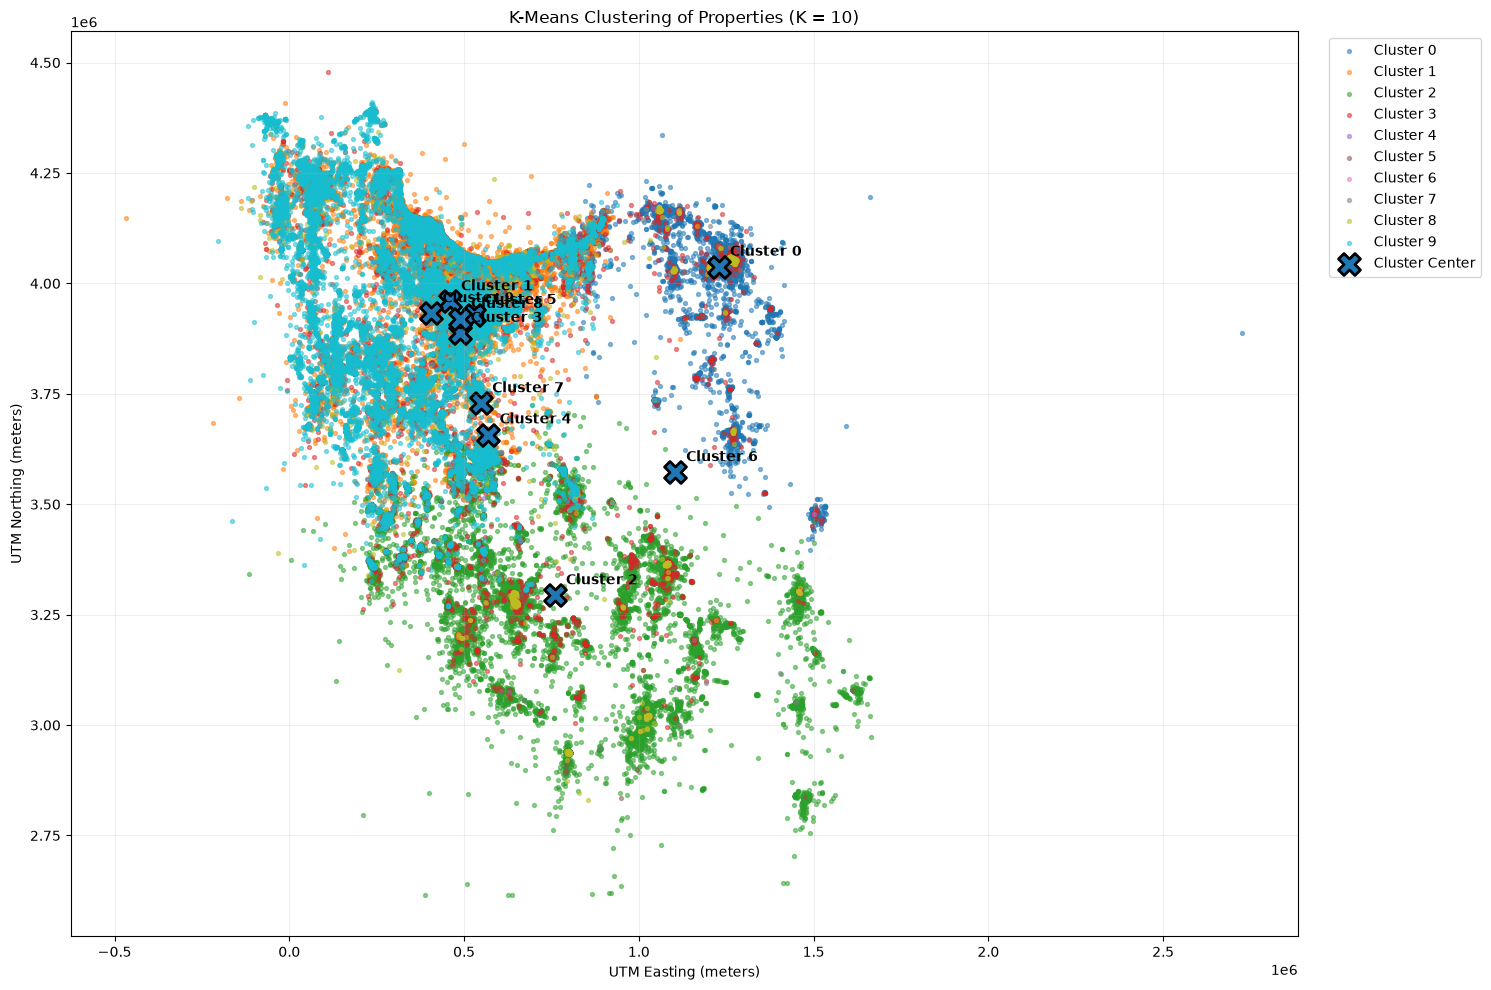

In [208]:
df_cluster = df_comp_price.copy()
df_cluster = df_cluster.dropna(subset=['location_latitude', 'location_longitude']).copy()
df_cluster = df_cluster.dropna(subset=['comparable_price']).copy()



transformer = Transformer.from_crs('EPSG:4326' , 'EPSG:32639' , always_xy=True)
df_cluster['utm_easting'], df_cluster['utm_northing'] = transformer.transform(df_cluster['location_longitude'].values , df_cluster['location_latitude'].values)


features = [
    'building_size',
    'land_size',
    'rooms_count',
    'floor',
    'total_floors_count',
    'construction_year',
    'amenity_score',
    'location_latitude',
    'location_longitude',
    'comparable_price'
]

df_cluster = df_cluster.dropna(subset=features).copy()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features])


kmeans = KMeans(n_clusters=10 , random_state=42 , n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)



plt.figure(figsize=(15, 10))

for cluster in range(10):
    data = df_cluster[df_cluster['cluster'] == cluster]
    plt.scatter(data['utm_easting'] , data['utm_northing'] , s=8 , alpha=0.5 , label=f'Cluster {cluster}')



centers = df_cluster.groupby('cluster')[['utm_easting', 'utm_northing']].mean()
plt.scatter(centers['utm_easting'] , centers['utm_northing'] , marker='X' , s=250 , edgecolors='black' , linewidths=2 , label='Cluster Center')



for cluster, row in centers.iterrows():
    plt.annotate(f'Cluster {cluster}' , (row['utm_easting'] , row['utm_northing']) , xytext=(8, 8) , textcoords='offset points' , fontsize=10 , fontweight='bold')



plt.xlabel('UTM Easting (meters)')
plt.ylabel('UTM Northing (meters)')
plt.title('K-Means Clustering of Properties (K = 10)')
plt.legend(bbox_to_anchor=(1.02, 1) , loc='upper left')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()
